MOUNT GOOGLE DRIVE

In [1]:
# Try to import Google Colab's Drive utility.
# If running locally, we will catch the ImportError and skip mounting.
try:
    from google.colab import drive
    # Mount Google Drive.
    drive.mount('/content/drive')
    IN_COLAB = True
    print("Mounted Google Drive successfully (running on Google Colab).")
except ImportError:
    IN_COLAB = False
    print("Running locally. Google Drive mount skipped.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


DEFINING PROJECT DIRECTORIES

In [2]:
# Import the os module for handling file and folder paths.
import os

# Define the root directory of the project.
# If in Google Colab, use the Google Drive path.
# If running locally, resolve the path relative to the notebook's location.
if 'IN_COLAB' in globals() and IN_COLAB:
    PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/Internship Work"
else:
    # Check if 'data' folder is in the current directory, or two levels up
    if os.path.exists("data"):
        PROJECT_DIR = os.getcwd()
    elif os.path.exists(os.path.join("..", "..", "data")):
        PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    else:
        # Default fallback to two levels up (the standard local project structure)
        PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

# Define the directory containing the processed clean dataset.
PROCESSED_DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "processed"
)

# Define the directory where figures will be saved.
FIGURES_DIR = os.path.join(
    PROJECT_DIR,
    "outputs",
    "figures"
)

# Define the directory where tables will be saved.
TABLES_DIR = os.path.join(
    PROJECT_DIR,
    "outputs",
    "tables"
)

# Define the directory where trained models may be saved.
MODELS_DIR = os.path.join(
    PROJECT_DIR,
    "outputs",
    "models"
)

# Create directories if they do not already exist.
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Display paths for confirmation.
print("Project directories configured successfully.")
print(f"Project root:   {PROJECT_DIR}")
print(f"Processed data: {PROCESSED_DATA_DIR}")
print(ff"Figures:        {FIGURES_DIR}")
print(ff"Tables:         {TABLES_DIR}")
print(ff"Models:         {MODELS_DIR}")


Project directories configured successfully.
Processed data: /content/drive/MyDrive/Colab Notebooks/Internship Work/data/processed
Figures:        /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures
Tables:         /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables
Models:         /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/models


Import Libraries

In [7]:
try:
    import catboost
    print("CatBoost is already installed.")
except ImportError:
    !pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [8]:
# -------------------------
# Data manipulation
# -------------------------

import pandas as pd
import numpy as np


# -------------------------
# Visualization
# -------------------------

import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------
# Machine Learning
# -------------------------

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)


# -------------------------
# Gradient Boosting Models
# -------------------------

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

# -------------------------
# Statistical testing
# -------------------------

from scipy.stats import wilcoxon


# -------------------------
# Reproducibility
# -------------------------

import random

# Define a global random seed.
RANDOM_STATE = 42

# Set NumPy random seed.
np.random.seed(RANDOM_STATE)

# Set Python random seed.
random.seed(RANDOM_STATE)


# -------------------------
# Visualization settings
# -------------------------

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

print("All libraries imported successfully.")




All libraries imported successfully.


Installing Optuna & SHAP

In [9]:
try:
    import optuna
    import shap
    print("Optuna and SHAP are already installed.")
except ImportError:
    # Install Optuna for hyperparameter optimization.
    !pip install -q optuna
    # Install SHAP for model explainability.
    !pip install -q shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 12.8 MB/s eta 0:00:00


In [10]:
import optuna
import shap

print("Optuna and SHAP imported successfully.")

Optuna and SHAP imported successfully.


Creating Reusable Utility Functions

In [11]:
# ============================================================
# FIGURE SAVING FUNCTION
# ============================================================

def save_figure(filename, dpi=300):
    """
    Save the currently active Matplotlib figure
    to the project's Google Drive figures directory.
    """

    # Construct the complete output path.
    filepath = os.path.join(
        FIGURES_DIR,
        filename
    )

    # Save the figure.
    plt.savefig(
        filepath,
        dpi=dpi,
        bbox_inches="tight"
    )

    # Display confirmation.
    print(f"Figure saved: {filepath}")

In [12]:
# ============================================================
# TABLE SAVING FUNCTION
# ============================================================

def save_table(dataframe, filename):
    """
    Save a Pandas DataFrame as a CSV file
    in the project's tables directory.
    """

    # Construct the complete file path.
    filepath = os.path.join(
        TABLES_DIR,
        filename
    )

    # Save the DataFrame.
    dataframe.to_csv(
        filepath,
        index=False
    )

    # Display confirmation.
    print(f"Table saved: {filepath}")

LOAD THE CLEANED DATASET

In [13]:
# Name of the cleaned dataset created in Notebook 1.
CLEAN_DATASET_NAME = "credit_card_default_clean.csv"

# Construct the complete path to the dataset.
CLEAN_DATASET_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    CLEAN_DATASET_NAME
)

# Load the cleaned dataset.
df = pd.read_csv(CLEAN_DATASET_PATH)

# Display basic information.
print("Clean dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

# Display the first few records.
display(df.head())

Clean dataset loaded successfully.
Dataset shape: (29965, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


VERIFY DATASET STRUCTURE

In [14]:
# Check the data types and missing values.
print("Dataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29965 entries, 0 to 29964
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIMIT_BAL  29965 non-null  float64
 1   SEX        29965 non-null  int64  
 2   EDUCATION  29965 non-null  int64  
 3   MARRIAGE   29965 non-null  int64  
 4   AGE        29965 non-null  int64  
 5   PAY_0      29965 non-null  int64  
 6   PAY_2      29965 non-null  int64  
 7   PAY_3      29965 non-null  int64  
 8   PAY_4      29965 non-null  int64  
 9   PAY_5      29965 non-null  int64  
 10  PAY_6      29965 non-null  int64  
 11  BILL_AMT1  29965 non-null  float64
 12  BILL_AMT2  29965 non-null  float64
 13  BILL_AMT3  29965 non-null  float64
 14  BILL_AMT4  29965 non-null  float64
 15  BILL_AMT5  29965 non-null  float64
 16  BILL_AMT6  29965 non-null  float64
 17  PAY_AMT1   29965 non-null  float64
 18  PAY_AMT2   29965 non-null  float64
 19  PAY_AMT3   29965 non-null

## Feature Engineering

The original dataset contains monthly repayment, billing, and payment records.

Instead of relying only on individual monthly variables, we create additional behavioural features that summarize the customer's overall credit behaviour.

These features represent:

- Repayment delay behaviour
- Payment consistency
- Billing behaviour
- Credit utilization
- Payment-to-bill relationship

In [15]:
# ============================================================
# DEFINE MONTHLY FEATURE GROUPS
# ============================================================

# Monthly repayment status features.
pay_status_cols = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

# Monthly bill amount features.
bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

# Monthly payment amount features.
payment_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

CREATE BEHAVIOURAL FEATURES (8 Behavioural Features)

In [16]:
# Average repayment status across the observed months.
df["AVG_PAY_STATUS"] = df[pay_status_cols].mean(axis=1)

# Maximum repayment delay recorded.
df["MAX_PAY_STATUS"] = df[pay_status_cols].max(axis=1)

# Number of months with a repayment delay.
df["DELAYED_MONTHS"] = (
    df[pay_status_cols] > 0
).sum(axis=1)

# Number of months with more severe repayment delays.
df["SEVERE_DELAY_MONTHS"] = (
    df[pay_status_cols] >= 2
).sum(axis=1)

# Average monthly bill amount.
df["AVG_BILL_AMT"] = df[bill_cols].mean(axis=1)

# Average monthly payment amount.
df["AVG_PAY_AMT"] = df[payment_cols].mean(axis=1)

# Total bill amount across the observed months.
df["TOTAL_BILL"] = df[bill_cols].sum(axis=1)

# Total payment amount across the observed months.
df["TOTAL_PAYMENT"] = df[payment_cols].sum(axis=1)

CREATE FINANCIAL BEHAVIOUR RATIOS

In [17]:
# Credit utilization:
# Average outstanding bill relative to available credit limit.
df["CREDIT_UTILIZATION"] = (
    df["AVG_BILL_AMT"] /
    df["LIMIT_BAL"].replace(0, np.nan)
)

# Payment ratio:
# Average payment relative to average billed amount.
df["PAYMENT_RATIO"] = (
    df["AVG_PAY_AMT"] /
    df["AVG_BILL_AMT"].replace(0, np.nan)
)

# Replace undefined and infinite values.
ratio_cols = [
    "CREDIT_UTILIZATION",
    "PAYMENT_RATIO"
]

df[ratio_cols] = (
    df[ratio_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print("Behavioural feature engineering completed.")

Behavioural feature engineering completed.


REVIEW ENGINEERED FEATURES

In [18]:
engineered_features = [
    "AVG_PAY_STATUS",
    "MAX_PAY_STATUS",
    "DELAYED_MONTHS",
    "SEVERE_DELAY_MONTHS",
    "AVG_BILL_AMT",
    "AVG_PAY_AMT",
    "TOTAL_BILL",
    "TOTAL_PAYMENT",
    "CREDIT_UTILIZATION",
    "PAYMENT_RATIO"
]

display(df[engineered_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
AVG_PAY_STATUS,29965.0,-0.180978,0.981368,-2.000000,-0.833333,0.000000,0.000000,6.000000e+00
MAX_PAY_STATUS,29965.0,0.439146,1.344934,-2.000000,0.000000,0.000000,2.000000,8.000000e+00
DELAYED_MONTHS,29965.0,0.834273,1.554821,0.000000,0.000000,0.000000,1.000000,6.000000e+00
SEVERE_DELAY_MONTHS,29965.0,0.710763,1.465053,0.000000,0.000000,0.000000,1.000000,6.000000e+00
AVG_BILL_AMT,29965.0,45029.328116,63279.074163,-56043.166667,4841.000000,21110.833333,57166.166667,8.773138e+05
AVG_PAY_AMT,29965.0,5281.297308,10142.306855,0.000000,1116.666667,2400.000000,5600.000000,6.273443e+05
TOTAL_BILL,29965.0,270175.968697,379674.444976,-336259.000000,29046.000000,126665.000000,342997.000000,5.263883e+06
TOTAL_PAYMENT,29965.0,31687.783848,60853.841129,0.000000,6700.000000,14400.000000,33600.000000,3.764066e+06
CREDIT_UTILIZATION,29965.0,0.373480,0.351867,-0.232590,0.030300,0.285629,0.688454,5.364308e+00
PAYMENT_RATIO,29965.0,0.381252,7.675470,-546.928571,0.040995,0.085097,0.587641,7.970000e+02


SEPARATE FEATURES AND TARGET

In [19]:
# Separate the target variable.
y = df["DEFAULT"]

# Remove the target variable from the input features.
X = df.drop(columns=["DEFAULT"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (29965, 33)
Target shape: (29965,)


Train-Test Split

In [20]:
# Keep 20% of the data for final testing.
# Stratification preserves the default/non-default ratio.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 23972
Testing samples: 5993

Training target distribution:
DEFAULT
0    0.778742
1    0.221258
Name: proportion, dtype: float64

Testing target distribution:
DEFAULT
0    0.778742
1    0.221258
Name: proportion, dtype: float64


DEFINE 6 BASELINE MODELS

In [21]:
# Logistic Regression requires feature scaling.
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

# Tree-based models do not require feature scaling.
models = {

    "Logistic Regression": logistic_model,

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE,
        verbosity=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=False,
        random_seed=RANDOM_STATE
    )
}

print(f"Total baseline models: {len(models)}")

Total baseline models: 6


DEFINE MODEL EVALUATION FUNCTION

In [22]:
def evaluate_model(model, X_data, y_data):
    """
    Train a model and calculate its main classification metrics.
    """

    # Train the model.
    model.fit(X_data, y_data)

    # Generate class predictions.
    predictions = model.predict(X_data)

    # Generate probability predictions for the positive class.
    probabilities = model.predict_proba(X_data)[:, 1]

    # Calculate evaluation metrics.
    results = {
        "Accuracy": accuracy_score(y_data, predictions),
        "Precision": precision_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_data,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_data,
            probabilities
        ),
        "PR-AUC": average_precision_score(
            y_data,
            probabilities
        )
    }

    return results

 STRATIFIED CROSS-VALIDATION

In [23]:
# Five-fold stratified cross-validation.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Metrics used for comparison.
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

BASELINE MODEL COMPARISON

In [24]:
baseline_results = []

for model_name, model in models.items():

    print(f"Evaluating {model_name}...")

    # Perform five-fold cross-validation.
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    # Store mean cross-validation results.
    baseline_results.append({

        "Model": model_name,

        "Accuracy": scores[
            "test_accuracy"
        ].mean(),

        "Precision": scores[
            "test_precision"
        ].mean(),

        "Recall": scores[
            "test_recall"
        ].mean(),

        "F1-Score": scores[
            "test_f1"
        ].mean(),

        "ROC-AUC": scores[
            "test_roc_auc"
        ].mean(),

        "Accuracy Std": scores[
            "test_accuracy"
        ].std()
    })

# Convert results to a DataFrame.
baseline_results_df = pd.DataFrame(
    baseline_results
)

# Sort by accuracy.
baseline_results_df = baseline_results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(baseline_results_df)

Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating CatBoost...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Accuracy Std
0,CatBoost,0.820874,0.672740,0.371609,0.478640,0.788024,0.005094
1,XGBoost,0.818955,0.661727,0.372551,0.476572,0.781094,0.005344
2,LightGBM,0.818872,0.663655,0.368404,0.473672,0.780570,0.004356
3,Random Forest,0.813866,0.634616,0.374437,0.470921,0.769587,0.004687
4,Decision Tree,0.812615,0.636476,0.358039,0.457663,0.745808,0.002361
5,Logistic Regression,0.811697,0.667254,0.297135,0.411132,0.764993,0.005921


In [99]:
# ============================================================
# DEFINE ORIGINAL AND ENGINEERED FEATURE SETS
# ============================================================

# The original UCI dataset contains 23 predictor variables.
# These are kept separately so that we can later perform
# an ablation study.

original_features = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",

    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",

    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",

    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

print(
    "Original features:",
    len(original_features)
)

print(
    "Engineered features:",
    len(engineered_features)
)

print(
    "Total features:",
    len(original_features) +
    len(engineered_features)
)

Original features: 23
Engineered features: 10
Total features: 33


SAVE BASELINE MODEL RESULTS

In [25]:
save_table(
    baseline_results_df,
    "baseline_model_comparison.csv"
)

Table saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables/baseline_model_comparison.csv


Figure saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/baseline_accuracy_comparison.png


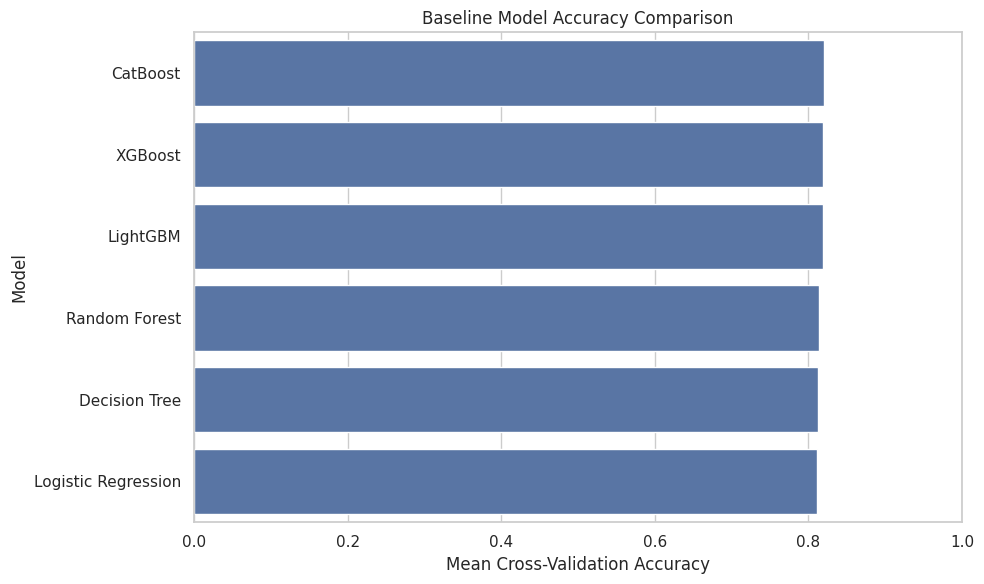

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=baseline_results_df,
    x="Accuracy",
    y="Model"
)

plt.title(
    "Baseline Model Accuracy Comparison"
)

plt.xlabel("Mean Cross-Validation Accuracy")
plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()

save_figure(
    "baseline_accuracy_comparison.png"
)

plt.show()

In [100]:
# ============================================================
# PREPARE ORIGINAL FEATURE DATA FOR ABLATION STUDY
# ============================================================

# Extract only the original features.
X_original = X[
    original_features
].copy()

# Use the exact same train-test indices that were created
# during the main modelling split.
X_original_train = X_original.loc[
    X_train.index
]

X_original_test = X_original.loc[
    X_test.index
]

print(
    "Original training shape:",
    X_original_train.shape
)

print(
    "Original testing shape:",
    X_original_test.shape
)

print(
    "Engineered training shape:",
    X_train.shape
)

print(
    "Engineered testing shape:",
    X_test.shape
)

Original training shape: (23972, 23)
Original testing shape: (5993, 23)
Engineered training shape: (23972, 33)
Engineered testing shape: (5993, 33)


SELECT TOP MODELS FOR HYPERPARAMETER OPTIMIZATION

# HYPERPARAMETER OPTIMIZATION

After comparing the baseline models using stratified cross-validation, the two strongest models are selected for further optimization.

The purpose of this stage is to identify better hyperparameter combinations than the initial manually selected configurations.

Optuna is used to search the hyperparameter space efficiently. The optimization objective is based on cross-validation accuracy, which is the primary performance metric for this project.

In [29]:
# Select the two strongest baseline models based on accuracy.
top_models = baseline_results_df.head(2)

print("Models selected for further optimization:")
display(
    top_models[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC"
        ]
    ]
)

Models selected for further optimization:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CatBoost,0.820874,0.672740,0.371609,0.478640,0.788024
1,XGBoost,0.818955,0.661727,0.372551,0.476572,0.781094


## CatBoost Hyperparameter Optimization

CatBoost was selected for optimization because it demonstrated strong performance during the baseline comparison.

Instead of manually testing a few parameter combinations, Optuna is used to explore a defined hyperparameter space.

The objective function evaluates each configuration using stratified cross-validation and returns the mean validation accuracy.

In [31]:
# ============================================================
# CATBOOST OPTUNA OBJECTIVE
# ============================================================

def catboost_objective(trial):

    # Define the hyperparameter search space.
    params = {

        # Number of boosting iterations.
        "iterations": trial.suggest_int(
            "iterations",
            300,
            1000
        ),

        # Depth of each decision tree.
        "depth": trial.suggest_int(
            "depth",
            4,
            10
        ),

        # Learning rate controls the contribution of each tree.
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.15,
            log=True
        ),

        # L2 regularization to control overfitting.
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            10
        ),

        # Controls the randomness used during training.
        "random_strength": trial.suggest_float(
            "random_strength",
            0,
            2
        ),

        # Controls the randomness of bootstrap sampling.
        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0,
            2
        ),

        "loss_function": "Logloss",

        "verbose": False,

        "random_seed": RANDOM_STATE
    }

    # Create the CatBoost model using trial parameters.
    model = CatBoostClassifier(**params)

    # Evaluate the parameter configuration using
    # stratified cross-validation.
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    # Return mean validation accuracy.
    return scores["test_score"].mean()

In [32]:
# ============================================================
# OPTIMIZE CATBOOST HYPERPARAMETERS
# ============================================================

# Create an Optuna study.
catboost_study = optuna.create_study(
    direction="maximize",
    study_name="CatBoost_Accuracy_Optimization"
)

# Run the optimization.
catboost_study.optimize(
    catboost_objective,
    n_trials=40,
    show_progress_bar=True
)

print("Optimization completed.")

print("\nBest Cross-Validation Accuracy:")
print(
    round(
        catboost_study.best_value,
        4
    )
)

print("\nBest Hyperparameters:")
print(
    catboost_study.best_params
)

[I 2026-07-19 16:03:39,032] A new study created in memory with name: CatBoost_Accuracy_Optimization


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-07-19 16:05:27,192] Trial 0 finished with value: 0.8172449834103543 and parameters: {'iterations': 352, 'depth': 10, 'learning_rate': 0.08279617140704082, 'l2_leaf_reg': 9.310664077447985, 'random_strength': 1.7281666482430593, 'bagging_temperature': 1.4047436905374413}. Best is trial 0 with value: 0.8172449834103543.
[I 2026-07-19 16:06:28,366] Trial 1 finished with value: 0.8194140746840747 and parameters: {'iterations': 377, 'depth': 9, 'learning_rate': 0.03617288011627374, 'l2_leaf_reg': 3.159020384183864, 'random_strength': 0.03495521279463554, 'bagging_temperature': 0.03882426193411703}. Best is trial 1 with value: 0.8194140746840747.
[I 2026-07-19 16:07:56,877] Trial 2 finished with value: 0.8199980597923282 and parameters: {'iterations': 915, 'depth': 8, 'learning_rate': 0.012483390497853625, 'l2_leaf_reg': 3.8673874356485247, 'random_strength': 1.9983254970650153, 'bagging_temperature': 0.6296523397734912}. Best is trial 2 with value: 0.8199980597923282.
[I 2026-07-19 

TRAIN OPTIMIZED CATBOOST MODEL

In [62]:
# Create the final CatBoost model using
# the best hyperparameters found by Optuna.
optimized_catboost = CatBoostClassifier(
    **catboost_study.best_params,
    verbose=False,
    random_seed=RANDOM_STATE
)

# Train the optimized model on the complete training set.
optimized_catboost.fit(
    X_train,
    y_train
)

print("Optimized CatBoost model trained successfully.")

Optimized CatBoost model trained successfully.


In [67]:
# ============================================================
# FAIR BASELINE VS OPTIMIZED CATBOOST COMPARISON
# ============================================================

# ------------------------------------------------------------
# 1. Train the baseline CatBoost model
# ------------------------------------------------------------

baseline_catboost = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=False,
    random_seed=RANDOM_STATE
)

baseline_catboost.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 2. Generate baseline predictions
# ------------------------------------------------------------

baseline_predictions = (
    baseline_catboost
    .predict(X_test)
    .astype(int)
    .ravel()
)

baseline_probabilities = (
    baseline_catboost
    .predict_proba(X_test)[:, 1]
)


# ------------------------------------------------------------
# 3. Generate optimized predictions
# ------------------------------------------------------------

optimized_predictions = (
    optimized_catboost
    .predict(X_test)
    .astype(int)
    .ravel()
)

optimized_probabilities = (
    optimized_catboost
    .predict_proba(X_test)[:, 1]
)


# ------------------------------------------------------------
# 4. Create a fair comparison table
# ------------------------------------------------------------

fair_catboost_comparison = pd.DataFrame([

    {
        "Model": "CatBoost Baseline",

        "Accuracy": accuracy_score(
            y_test,
            baseline_predictions
        ),

        "Precision": precision_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_test,
            baseline_predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            baseline_probabilities
        )
    },

    {
        "Model": "CatBoost + Optuna",

        "Accuracy": accuracy_score(
            y_test,
            optimized_predictions
        ),

        "Precision": precision_score(
            y_test,
            optimized_predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            optimized_predictions,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_test,
            optimized_predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            optimized_probabilities
        )
    }

])

display(
    fair_catboost_comparison
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CatBoost Baseline,0.818288,0.665272,0.359729,0.46696,0.778886
1,CatBoost + Optuna,0.818955,0.670922,0.356712,0.46578,0.777994


# THRESHOLD OPTIMIZATION

Most binary classifiers use 0.50 as the default probability threshold.

However, this threshold is not necessarily optimal for maximizing accuracy on a class-imbalanced dataset.

Therefore, multiple thresholds are evaluated using out-of-fold predictions generated from the training data.

The threshold producing the highest cross-validated accuracy is selected and then applied once to the held-out test set.

In [68]:
# ============================================================
# THRESHOLD OPTIMIZATION FOR OPTIMIZED CATBOOST
# ============================================================

# Generate out-of-fold probabilities using the optimized model.
optimized_oof_probabilities = cross_val_predict(
    optimized_catboost,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [69]:
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.01):

    predictions = (
        catboost_oof_probabilities >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_train,
            predictions
        ),

        "Precision": precision_score(
            y_train,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_train,
            predictions,
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_train,
            predictions,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

best_threshold_row = (
    threshold_results_df
    .sort_values(
        by="Accuracy",
        ascending=False
    )
    .iloc[0]
)

BEST_BASELINE_THRESHOLD = (
    best_threshold_row["Threshold"]
)

print(
    f"Best threshold: "
    f"{BEST_BASELINE_THRESHOLD:.2f}"
)

print(
    f"OOF accuracy: "
    f"{best_threshold_row['Accuracy']:.4f}"
)

Best threshold: 0.49
OOF accuracy: 0.8205


FINAL TEST EVALUATION (On Untouched Test Set)

In [70]:
# Get the baseline CatBoost model instance.
baseline_catboost_model = models["CatBoost"]

# Train the baseline CatBoost model on the training data.
baseline_catboost_model.fit(X_train, y_train)

# Generate test probabilities from baseline CatBoost.
baseline_test_probabilities = (
    baseline_catboost_model
    .predict_proba(X_test)[:, 1]
)

# Apply optimized threshold.
baseline_threshold_predictions = (
    baseline_test_probabilities
    >= BEST_BASELINE_THRESHOLD
).astype(int)

print(
    "Threshold-optimized baseline CatBoost accuracy:",
    accuracy_score(
        y_test,
        baseline_threshold_predictions
    )
)

Threshold-optimized baseline CatBoost accuracy: 0.8181211413315534


LIGHTGBM OPTUNA

In [40]:
def lightgbm_objective(trial):

    # Define the hyperparameter search space.
    params = {

        # Number of boosting trees.
        "n_estimators": trial.suggest_int(
            "n_estimators",
            300,
            1000
        ),

        # Learning rate of the model.
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.15,
            log=True
        ),

        # Number of leaves in each tree.
        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            100
        ),

        # Maximum tree depth.
        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            12
        ),

        # Minimum number of samples in a leaf.
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            10,
            100
        ),

        # Fraction of samples used for each tree.
        "subsample": trial.suggest_float(
            "subsample",
            0.7,
            1.0
        ),

        # Fraction of features used for each tree.
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.7,
            1.0
        ),

        # L1 regularization.
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0,
            5
        ),

        # L2 regularization.
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0,
            5
        ),

        "random_state": RANDOM_STATE,

        "verbosity": -1
    }

    # Create the LightGBM model.
    model = LGBMClassifier(**params)

    # Evaluate the current parameter combination
    # using stratified cross-validation.
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    # Return the mean cross-validation accuracy.
    return scores["test_score"].mean()

In [41]:
# ============================================================
# RUN LIGHTGBM OPTUNA OPTIMIZATION
# ============================================================

# Create an Optuna study for LightGBM.
lightgbm_study = optuna.create_study(
    direction="maximize",
    study_name="LightGBM_Accuracy_Optimization"
)

# Search for the best hyperparameters.
lightgbm_study.optimize(
    lightgbm_objective,
    n_trials=40,
    show_progress_bar=True
)

print("LightGBM optimization completed.")

print("\nBest LightGBM CV Accuracy:")
print(
    round(
        lightgbm_study.best_value,
        4
    )
)

print("\nBest LightGBM Parameters:")
print(
    lightgbm_study.best_params
)

[I 2026-07-19 17:03:41,309] A new study created in memory with name: LightGBM_Accuracy_Optimization


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-07-19 17:04:00,758] Trial 0 finished with value: 0.8138241710723737 and parameters: {'n_estimators': 645, 'learning_rate': 0.12839666173227923, 'num_leaves': 47, 'max_depth': 5, 'min_child_samples': 81, 'subsample': 0.8287201211314262, 'colsample_bytree': 0.8559591450902888, 'reg_alpha': 2.3871126980943203, 'reg_lambda': 0.7458575116292526}. Best is trial 0 with value: 0.8138241710723737.
[I 2026-07-19 17:04:17,222] Trial 1 finished with value: 0.8086516035207374 and parameters: {'n_estimators': 704, 'learning_rate': 0.1322193493062035, 'num_leaves': 90, 'max_depth': 11, 'min_child_samples': 87, 'subsample': 0.9287523389114961, 'colsample_bytree': 0.7867063826642291, 'reg_alpha': 3.9519332383040195, 'reg_lambda': 4.580291526435945}. Best is trial 0 with value: 0.8138241710723737.
[I 2026-07-19 17:04:24,575] Trial 2 finished with value: 0.8207488505574616 and parameters: {'n_estimators': 403, 'learning_rate': 0.022016306777759693, 'num_leaves': 35, 'max_depth': 5, 'min_child_sam

TRAIN OPTIMIZED LIGHTGBM

In [42]:
# Create LightGBM using the best parameters
# discovered by Optuna.
optimized_lightgbm = LGBMClassifier(
    **lightgbm_study.best_params,
    random_state=RANDOM_STATE,
    verbosity=-1
)

# Train the optimized model.
optimized_lightgbm.fit(
    X_train,
    y_train
)

print("Optimized LightGBM model trained successfully.")

Optimized LightGBM model trained successfully.


EVALUATE OPTIMIZED LIGHTGBM

In [44]:
# Generate probability predictions.
lightgbm_probabilities = (
    optimized_lightgbm
    .predict_proba(X_test)[:, 1]
)

# Use the default 0.5 threshold for now.
lightgbm_predictions = (
    lightgbm_probabilities >= 0.5
).astype(int)

# Calculate evaluation metrics.
lightgbm_results = {

    "Model": "LightGBM + Optuna",

    "Threshold": 0.5,

    "Accuracy": accuracy_score(
        y_test,
        lightgbm_predictions
    ),

    "Precision": precision_score(
        y_test,
        lightgbm_predictions,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        lightgbm_predictions,
        zero_division=0
    ),

    "F1-Score": f1_score(
        y_test,
        lightgbm_predictions,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        lightgbm_probabilities
    )
}

lightgbm_results_df = pd.DataFrame(
    [lightgbm_results]
)

display(lightgbm_results_df)

,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM + Optuna,0.5,0.818288,0.670504,0.351433,0.461158,0.778452


In [98]:
import joblib

print("Saving all models...")

# Save baseline models
for model_name, model in models.items():
    sanitized_model_name = model_name.replace(' ', '_').lower()
    filepath = os.path.join(MODELS_DIR, f"baseline_{sanitized_model_name}_model.joblib")
    joblib.dump(model, filepath)
    print(f"Saved baseline {model_name} model to {filepath}")

# Save optimized CatBoost model
optimized_catboost_filepath = os.path.join(MODELS_DIR, "optimized_catboost_model.joblib")
joblib.dump(optimized_catboost, optimized_catboost_filepath)
print(f"Saved optimized CatBoost model to {optimized_catboost_filepath}")

# Save optimized LightGBM model
optimized_lightgbm_filepath = os.path.join(MODELS_DIR, "optimized_lightgbm_model.joblib")
joblib.dump(optimized_lightgbm, optimized_lightgbm_filepath)
print(f"Saved optimized LightGBM model to {optimized_lightgbm_filepath}")

print("All models saved successfully.")

Saving all models...
Saved baseline Logistic Regression model to /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/models/baseline_logistic_regression_model.joblib
Saved baseline Decision Tree model to /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/models/baseline_decision_tree_model.joblib
Saved baseline Random Forest model to /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/models/baseline_random_forest_model.joblib
Saved baseline XGBoost model to /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/models/baseline_xgboost_model.joblib
Saved baseline LightGBM model to /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/models/baseline_lightgbm_model.joblib
Saved baseline CatBoost model to /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/models/baseline_catboost_model.joblib
Saved optimized CatBoost model to /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/models/optimized_catboost_model.joblib

SAVE FINAL MODEL RESULTS

In [75]:
# Save final performance metrics.
save_table(
    final_results_df,
    "final_model_results.csv"
)

# Save threshold experiment results.
save_table(
    threshold_results_df,
    "threshold_optimization_results.csv"
)

Table saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables/final_model_results.csv
Table saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables/threshold_optimization_results.csv


FINAL MODEL COMPARISON TABLE

In [74]:
# Select the relevant columns from baseline results.
baseline_comparison = baseline_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].copy()

# Select the same columns from the optimized CatBoost results.
catboost_comparison = final_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].copy()

# Select the same columns from the optimized LightGBM results.
lightgbm_comparison = lightgbm_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
].copy()

# Combine all model results into one final table.
final_model_comparison = pd.concat(
    [
        baseline_comparison,
        catboost_comparison,
        lightgbm_comparison
    ],
    ignore_index=True
)

# Sort models by accuracy.
final_model_comparison = (
    final_model_comparison
    .sort_values(
        by="Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the final comparison table.
display(final_model_comparison)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,CatBoost,0.820874,0.672740,0.371609,0.478640,0.788024
1,Optimized CatBoost,0.818955,0.670922,0.356712,0.465780,0.777994
2,XGBoost,0.818955,0.661727,0.372551,0.476572,0.781094
3,LightGBM,0.818872,0.663655,0.368404,0.473672,0.780570
4,LightGBM + Optuna,0.818288,0.670504,0.351433,0.461158,0.778452
5,Random Forest,0.813866,0.634616,0.374437,0.470921,0.769587
6,Decision Tree,0.812615,0.636476,0.358039,0.457663,0.745808
7,Logistic Regression,0.811697,0.667254,0.297135,0.411132,0.764993


# ABLATION STUDY — ORIGINAL VS ENGINEERED FEATURES

This experiment evaluates whether the engineered behavioural features
provide additional predictive value beyond the original dataset features.

Two CatBoost models are trained using the same train-test split:

1. Original features only
2. Original + engineered features

In [102]:
# ============================================================
# TABLE ABLATION STUDY
# ============================================================

# ------------------------------------------------------------
# Train CatBoost using original features only
# ------------------------------------------------------------

ablation_original_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=False,
    random_seed=RANDOM_STATE
)

ablation_original_model.fit(
    X_original_train,
    y_train
)


# Generate predictions.
original_predictions = (
    ablation_original_model
    .predict(X_original_test)
    .astype(int)
    .ravel()
)

# Generate probability predictions.
original_probabilities = (
    ablation_original_model
    .predict_proba(
        X_original_test
    )[:, 1]
)


# ------------------------------------------------------------
# Evaluate engineered-feature model
# ------------------------------------------------------------

# The tuned CatBoost model has already been trained
# using the complete engineered feature set.

engineered_predictions = test_predictions

engineered_probabilities = test_probabilities


# ------------------------------------------------------------
# Create ablation results table
# ------------------------------------------------------------

ablation_results = pd.DataFrame([

    {
        "Feature Set": "Original Features Only",

        "ROC-AUC": roc_auc_score(
            y_test,
            original_probabilities
        ),

        "Accuracy": accuracy_score(
            y_test,
            original_predictions
        ),

        "F1-Score": f1_score(
            y_test,
            original_predictions,
            zero_division=0
        ),

        "Average Precision": average_precision_score(
            y_test,
            original_probabilities
        )
    },

    {
        "Feature Set": "Original + Engineered Features",

        "ROC-AUC": roc_auc_score(
            y_test,
            engineered_probabilities
        ),

        "Accuracy": accuracy_score(
            y_test,
            engineered_predictions
        ),

        "F1-Score": f1_score(
            y_test,
            engineered_predictions,
            zero_division=0
        ),

        "Average Precision": average_precision_score(
            y_test,
            engineered_probabilities
        )
    }

])

display(ablation_results)

,Feature Set,ROC-AUC,Accuracy,F1-Score,Average Precision
0,Original Features Only,0.776288,0.818789,0.47076,0.555418
1,Original + Engineered Features,0.777994,0.818955,0.46578,0.565227


In [103]:
# Save Table.
save_table(
    ablation_results,
    "table_5_ablation_study.csv"
)

Table saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables/table_5_ablation_study.csv


Baseline CatBoost for the engineered feature

In [104]:
ablation_engineered_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=False,
    random_seed=RANDOM_STATE
)

ablation_engineered_model.fit(
    X_train,
    y_train
)

engineered_ablation_predictions = (
    ablation_engineered_model
    .predict(X_test)
    .astype(int)
    .ravel()
)

engineered_ablation_probabilities = (
    ablation_engineered_model
    .predict_proba(X_test)[:, 1]
)

# FIVE-FOLD CROSS-VALIDATION ABLATION STUDY

The contribution of the engineered features is further evaluated
using identical five-fold stratified cross-validation splits.

Each fold trains two CatBoost models:

1. Original features only
2. Original + engineered features

In [105]:
# ============================================================
# FIVE-FOLD CV
# ORIGINAL VS ENGINEERED FEATURES
# ============================================================

original_cv_scores = []

engineered_cv_scores = []

fold_results = []


# Use the existing five-fold stratified CV object.
for fold_number, (
    train_indices,
    validation_indices
) in enumerate(
    cv.split(
        X_train,
        y_train
    ),
    start=1
):

    # --------------------------------------------------------
    # ORIGINAL FEATURES
    # --------------------------------------------------------

    X_original_train_fold = (
        X_original_train.iloc[
            train_indices
        ]
    )

    X_original_val_fold = (
        X_original_train.iloc[
            validation_indices
        ]
    )


    # --------------------------------------------------------
    # ENGINEERED FEATURES
    # --------------------------------------------------------

    X_engineered_train_fold = (
        X_train.iloc[
            train_indices
        ]
    )

    X_engineered_val_fold = (
        X_train.iloc[
            validation_indices
        ]
    )


    # Target values.
    y_train_fold = (
        y_train.iloc[
            train_indices
        ]
    )

    y_val_fold = (
        y_train.iloc[
            validation_indices
        ]
    )


    # --------------------------------------------------------
    # Train original-feature CatBoost
    # --------------------------------------------------------

    original_model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=False,
        random_seed=RANDOM_STATE
    )

    original_model.fit(
        X_original_train_fold,
        y_train_fold
    )

    original_probabilities = (
        original_model
        .predict_proba(
            X_original_val_fold
        )[:, 1]
    )

    original_auc = roc_auc_score(
        y_val_fold,
        original_probabilities
    )


    # --------------------------------------------------------
    # Train engineered-feature CatBoost
    # --------------------------------------------------------

    engineered_model = CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=False,
        random_seed=RANDOM_STATE
    )

    engineered_model.fit(
        X_engineered_train_fold,
        y_train_fold
    )

    engineered_probabilities = (
        engineered_model
        .predict_proba(
            X_engineered_val_fold
        )[:, 1]
    )

    engineered_auc = roc_auc_score(
        y_val_fold,
        engineered_probabilities
    )


    # Store fold results.
    fold_results.append({

        "Fold": fold_number,

        "Original ROC-AUC": original_auc,

        "Engineered ROC-AUC": engineered_auc,

        "Difference": (
            engineered_auc -
            original_auc
        )
    })


# Convert fold results to DataFrame.
table_fold_results = pd.DataFrame(
    fold_results
)

display(
    table_fold_results
)

,Fold,Original ROC-AUC,Engineered ROC-AUC,Difference
0,1,0.789916,0.792156,0.002240
1,2,0.788338,0.791330,0.002993
2,3,0.782034,0.781715,-0.000318
3,4,0.772368,0.774932,0.002565
4,5,0.797077,0.799986,0.002909


In [107]:
# ============================================================
# TABLE SUMMARY
# ============================================================

table_fold_summary = pd.DataFrame([

    {
        "Feature Set": "Original Features",

        "Mean ROC-AUC": (
            table_fold_results[
                "Original ROC-AUC"
            ].mean()
        ),

        "Std ROC-AUC": (
            table_fold_results[
                "Original ROC-AUC"
            ].std()
        )
    },

    {
        "Feature Set": "Original + Engineered Features",

        "Mean ROC-AUC": (
            table_fold_results[
                "Engineered ROC-AUC"
            ].mean()
        ),

        "Std ROC-AUC": (
            table_fold_results[
                "Engineered ROC-AUC"
            ].std()
        )
    }

])

display(table_fold_summary)

,Feature Set,Mean ROC-AUC,Std ROC-AUC
0,Original Features,0.785946,0.009288
1,Original + Engineered Features,0.788024,0.009776


 Save fold-level results

In [108]:
save_table(
    table_fold_results,
    "table_6_fold_level_results.csv"
)

# Save summary results.
save_table(
    table_fold_summary,
    "table_6_original_vs_engineered_summary.csv"
)

Table saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables/table_6_fold_level_results.csv
Table saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables/table_6_original_vs_engineered_summary.csv


 ROC CURVE OF TUNED CATBOOST

Figure saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/figure_2_roc_curve_tuned_catboost.png


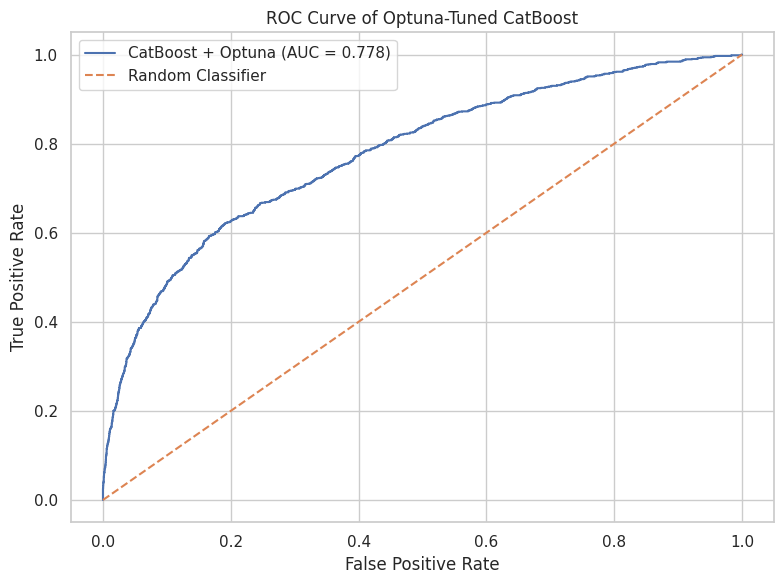

In [85]:
# Calculate False Positive Rate and True Positive Rate.
fpr, tpr, thresholds = roc_curve(
    y_test,
    test_probabilities
)

# Calculate ROC-AUC.
roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

# Create the ROC curve.
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"CatBoost + Optuna (AUC = {roc_auc:.3f})"
)

# Add the random classifier baseline.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve of Optuna-Tuned CatBoost"
)

plt.legend()

plt.tight_layout()

# Save Figure 2.
save_figure(
    "figure_2_roc_curve_tuned_catboost.png"
)

plt.show()

CONFUSION MATRIX

Figure saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/figure_3_confusion_matrix_tuned_catboost.png


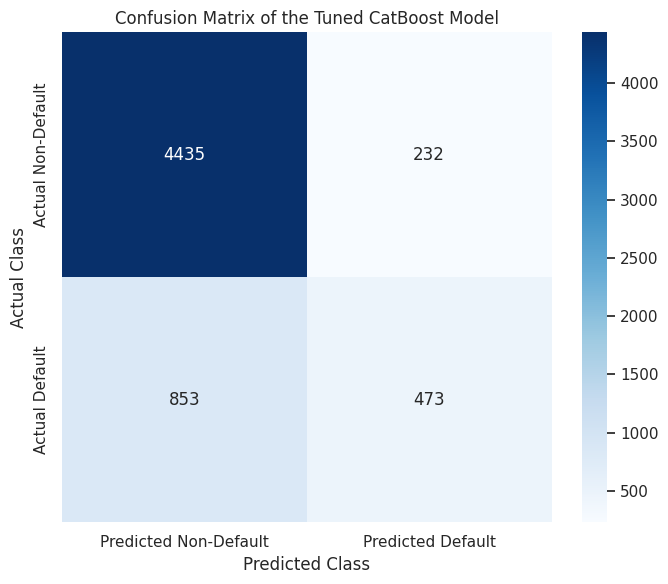

In [86]:
# Calculate the confusion matrix.
cm = confusion_matrix(
    y_test,
    test_predictions
)

# Create the plot.
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Non-Default",
        "Predicted Default"
    ],
    yticklabels=[
        "Actual Non-Default",
        "Actual Default"
    ]
)

plt.title(
    "Confusion Matrix of the Tuned CatBoost Model"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

# Save Figure 3.
save_figure(
    "figure_3_confusion_matrix_tuned_catboost.png"
)

plt.show()

FIVE-FOLD CROSS-VALIDATION ROC-AUC

In [89]:
from sklearn.model_selection import cross_val_score

# Store cross-validation results.
cv_roc_auc_results = []

# Evaluate each baseline model.
for model_name, model in models.items():

    # Perform five-fold cross-validation.
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    # Store the results.
    cv_roc_auc_results.append({

        "Model": model_name,

        "Mean ROC-AUC": scores.mean(),

        "Std ROC-AUC": scores.std(),

        "ROC-AUC (Mean \u00b1 Std)": (
            f"{scores.mean():.4f} \u00b1 "
            f"{scores.std():.4f}"
        )
    })

# Convert results to DataFrame.
cv_roc_auc_df = pd.DataFrame(
    cv_roc_auc_results
)

# Sort by mean ROC-AUC.
cv_roc_auc_df = (
    cv_roc_auc_df
    .sort_values(
        "Mean ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(cv_roc_auc_df)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Model,Mean ROC-AUC,Std ROC-AUC,ROC-AUC (Mean ± Std)
0,CatBoost,0.788024,0.008744,0.7880 ± 0.0087
1,XGBoost,0.781094,0.007893,0.7811 ± 0.0079
2,LightGBM,0.780570,0.009568,0.7806 ± 0.0096
3,Random Forest,0.769587,0.006606,0.7696 ± 0.0066
4,Logistic Regression,0.764993,0.008968,0.7650 ± 0.0090
5,Decision Tree,0.745808,0.010290,0.7458 ± 0.0103


In [90]:
# Save Table
save_table(
    cv_roc_auc_df,
    "table_five_fold_cv_roc_auc.csv"
)

Table saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables/table_five_fold_cv_roc_auc.csv


CROSS-VALIDATION ROC-AUC DISTRIBUTION

In [92]:
cv_distribution = []

for model_name, model in models.items():

    # Get ROC-AUC score for each fold.
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    # Store each fold score.
    for fold_number, score in enumerate(
        scores,
        start=1
    ):

        cv_distribution.append({

            "Model": model_name,

            "Fold": fold_number,

            "ROC-AUC": score
        })

# Convert to DataFrame.
cv_distribution_df = pd.DataFrame(
    cv_distribution
)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Figure saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/figure_4_cv_roc_auc_distribution.png


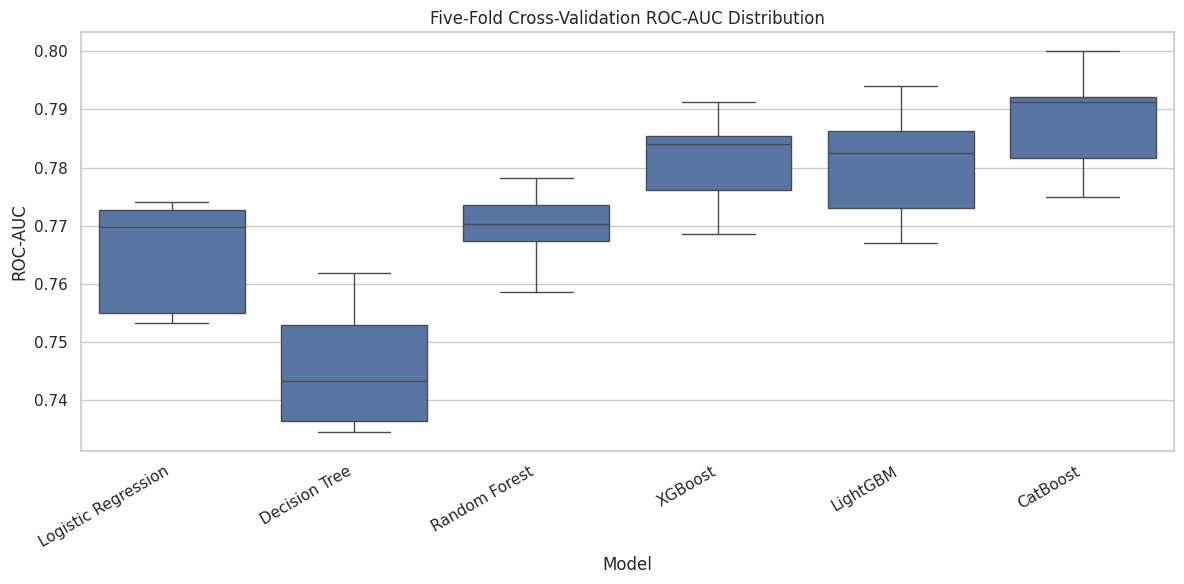

In [93]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=cv_distribution_df,
    x="Model",
    y="ROC-AUC"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.title(
    "Five-Fold Cross-Validation ROC-AUC Distribution"
)

plt.tight_layout()

# Save Figure 4.
save_figure(
    "figure_4_cv_roc_auc_distribution.png"
)

plt.show()

CATBOOST NATIVE FEATURE IMPORTANCE



In [95]:
# Extract feature importance values.
feature_importance_df = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": optimized_catboost
    .get_feature_importance()
})

# Sort by importance.
feature_importance_df = (
    feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add rank.
feature_importance_df["Rank"] = (
    feature_importance_df.index + 1
)

display(
    feature_importance_df.head(8)
)

,Feature,Importance,Rank
0,PAY_0,18.833676,1
1,CREDIT_UTILIZATION,7.434591,2
2,MAX_PAY_STATUS,5.731930,3
3,LIMIT_BAL,5.208802,4
4,BILL_AMT1,5.183328,5
5,SEVERE_DELAY_MONTHS,4.059172,6
6,DELAYED_MONTHS,3.585583,7
7,AVG_PAY_STATUS,3.501519,8


In [96]:
# Save top eight predictors.
top_8_features = feature_importance_df.head(8)

save_table(
    top_8_features,
    "top_8_catboost_predictors.csv"
)

Table saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables/top_8_catboost_predictors.csv


CATBOOST FEATURE IMPORTANCE

Figure saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/figure_5_catboost_feature_importance.png


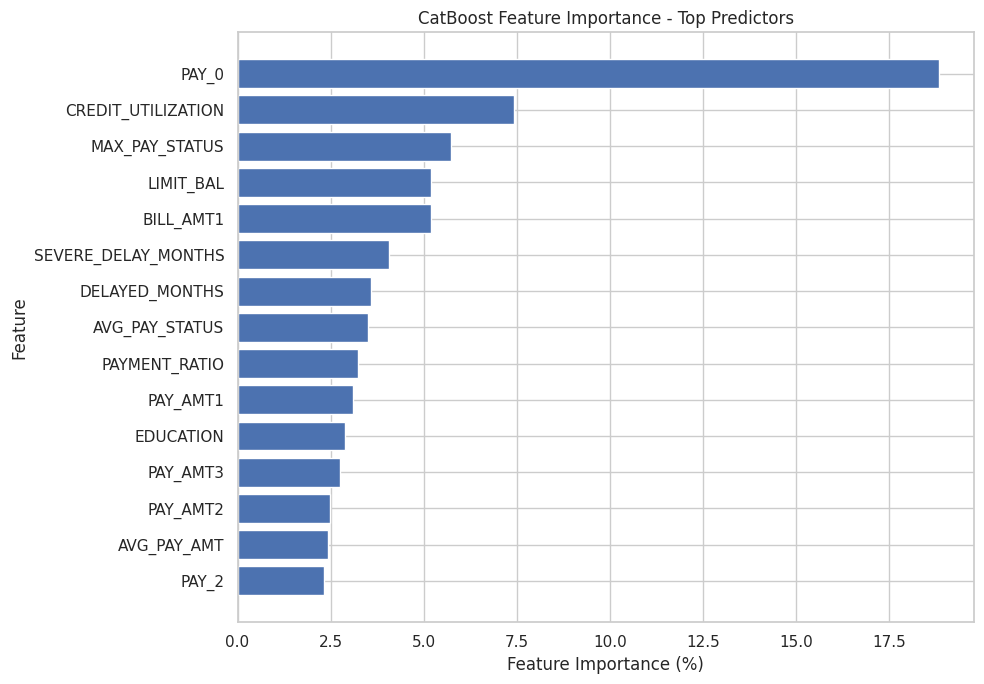

In [97]:
top_features_plot = (
    feature_importance_df
    .head(15)
    .sort_values(
        "Importance"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_plot["Feature"],
    top_features_plot["Importance"]
)

plt.xlabel(
    "Feature Importance (%)"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "CatBoost Feature Importance - Top Predictors"
)

plt.tight_layout()

save_figure(
    "figure_5_catboost_feature_importance.png"
)

plt.show()

SHAP ANALYSIS: CREATE EXPLAINER

In [76]:
# Create a TreeExplainer for the final optimized CatBoost model.
# TreeExplainer is designed for tree-based models such as CatBoost.
explainer = shap.TreeExplainer(
    optimized_catboost
)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


SHAP ANALYSIS: CALCULATE SHAP VALUES

In [78]:
# Calculate SHAP values for the held-out test set.
# We use X_test because these are unseen customer records
# used for final model evaluation.

shap_values = explainer.shap_values(
    X_test
)

print("SHAP values calculated successfully.")
print(
    f"SHAP matrix shape: {shap_values.shape}"
)

SHAP values calculated successfully.
SHAP matrix shape: (5993, 33)


VERIFY SHAP OUTPUT

In [79]:
print(
    "Number of test samples:",
    X_test.shape[0]
)

print(
    "Number of features:",
    X_test.shape[1]
)

print(
    "SHAP values shape:",
    shap_values.shape
)

Number of test samples: 5993
Number of features: 33
SHAP values shape: (5993, 33)


SHAP GLOBAL FEATURE IMPORTANCE

In [80]:
# Calculate the mean absolute SHAP value for every feature.
# This represents the average magnitude of each feature's
# contribution to the model's predictions.
shap_importance_df = pd.DataFrame({

    "Feature": X_test.columns,

    "Mean_Absolute_SHAP": np.abs(
        shap_values
    ).mean(axis=0)

})

# Sort features from most important to least important.
shap_importance_df = (
    shap_importance_df
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# Add feature ranking.
shap_importance_df["Rank"] = (
    shap_importance_df.index + 1
)

display(
    shap_importance_df.head(10)
)

,Feature,Mean_Absolute_SHAP,Rank
0,PAY_0,0.280123,1
1,CREDIT_UTILIZATION,0.133281,2
2,MAX_PAY_STATUS,0.124997,3
3,SEVERE_DELAY_MONTHS,0.096050,4
4,DELAYED_MONTHS,0.087080,5
5,LIMIT_BAL,0.086946,6
6,BILL_AMT1,0.073861,7
7,AVG_PAY_STATUS,0.069850,8
8,PAY_AMT1,0.052632,9
9,AVG_PAY_AMT,0.049943,10


In [81]:
# Save the complete SHAP feature importance table.
save_table(
    shap_importance_df,
    "shap_global_feature_importance.csv"
)

Table saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/tables/shap_global_feature_importance.csv


SHAP SUMMARY PLOT

/tmp/ipykernel_978/3845628589.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


Figure saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/figure_6_shap_summary_plot.png


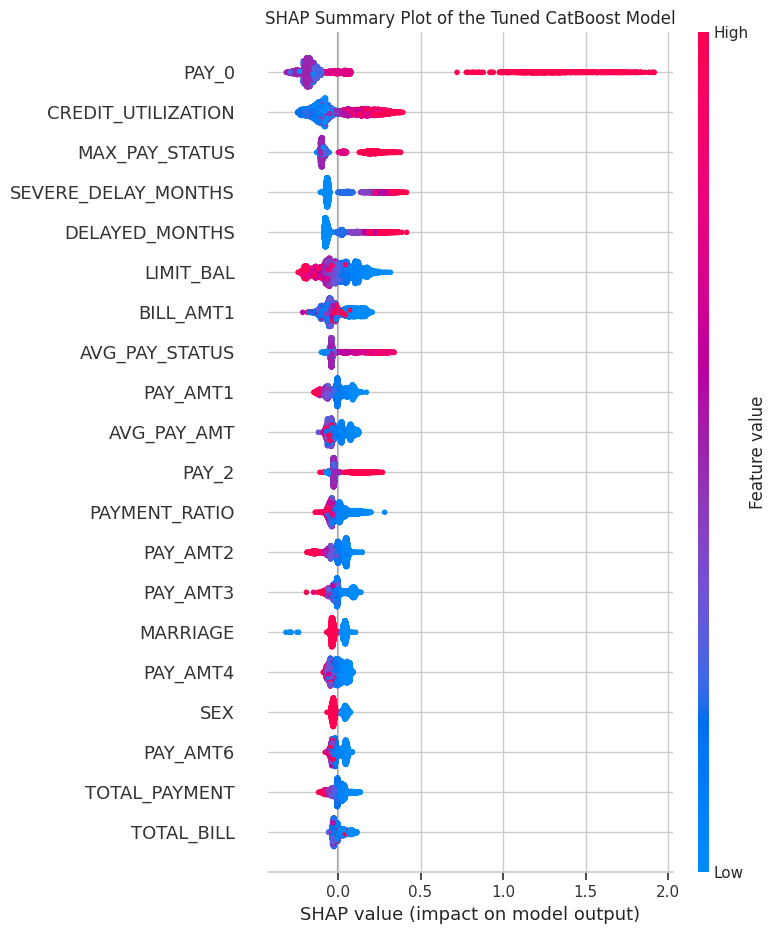

In [84]:
# Create the SHAP beeswarm summary plot.
# This shows:
# - Feature importance
# - Direction of impact
# - Magnitude of impact
# - Distribution across individual customers

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title(
    "SHAP Summary Plot of the Tuned CatBoost Model"
)

plt.tight_layout()

# Save Figure 6 to Google Drive.
save_figure(
    "figure_6_shap_summary_plot.png"
)

plt.show()

MEAN ABSOLUTE SHAP FEATURE IMPORTANCE

Figure saved: /content/drive/MyDrive/Colab Notebooks/Internship Work/outputs/figures/figure_7_mean_absolute_shap_importance.png


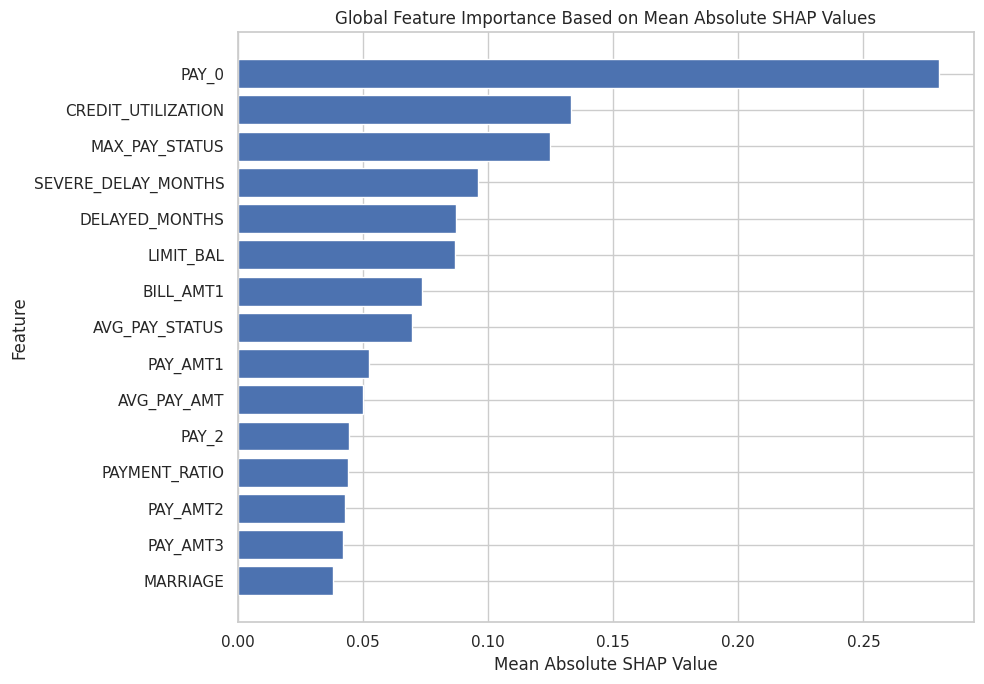

In [83]:
# Select the top 15 features for a readable graph.
top_shap_features = (
    shap_importance_df
    .head(15)
    .sort_values(
        by="Mean_Absolute_SHAP"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_shap_features["Feature"],
    top_shap_features["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Global Feature Importance Based on Mean Absolute SHAP Values"
)

plt.tight_layout()

# Save Figure 7 to Google Drive.
save_figure(
    "figure_7_mean_absolute_shap_importance.png"
)

plt.show()

#Total Features-10

In [109]:
# Number of rows and features
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Number of samples: 29965
Number of features: 33


In [110]:
print("Total features:", len(X.columns))
print(X.columns.tolist())

Total features: 33
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_PAY_STATUS', 'MAX_PAY_STATUS', 'DELAYED_MONTHS', 'SEVERE_DELAY_MONTHS', 'AVG_BILL_AMT', 'AVG_PAY_AMT', 'TOTAL_BILL', 'TOTAL_PAYMENT', 'CREDIT_UTILIZATION', 'PAYMENT_RATIO']
